In [74]:
import sys
print(sys.executable)

/Users/srishtisindgi/rainfall-ml-project/venv/bin/python


# Rainfall Prediction Using Machine Learning

## Objective: Predict daily rainfall using historical weather data from NASA POWER dataset.

Target Variable:
PRECTOTCORR → Daily Rainfall (mm)

Workflow:
1. Data Loading
2. Data Understanding
3. Data Cleaning
4. Feature Engineering
5. Exploratory Data Analysis
6. Feature Selection
7. PCA (Dimensionality Reduction)
8. Train/Test Split
9. Model Training
10. Model Evaluation
11. Model Comparison
12. Future Rainfall Prediction

# 1. Import Libraries

In [75]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

import warnings
warnings.filterwarnings("ignore")

# 2. Load Dataset

In [76]:
with open("../data/rainfall.csv") as f:
    for i in range(10):
        print(f.readline())

-BEGIN HEADER-

NASA/POWER Source Native Resolution Daily Data 

Dates (month/day/year): 01/01/1995 through 12/31/2025 in LST

Location: latitude  18.8209   longitude 98.9899 

elevation from MERRA-2: Average for 0.5 x 0.625 degree lat/lon region = 759.08 meters

The value for missing source data that cannot be computed or is outside of the sources availability range: -999 

parameter(s): 

ALLSKY_SFC_SW_DWN     CERES SYN1deg All Sky Surface Shortwave Downward Irradiance (MJ/m^2/day) 

ALLSKY_SFC_SW_DNI     CERES SYN1deg All Sky Surface Shortwave Downward Direct Normal Irradiance (MJ/m^2/day) 

T2M                   MERRA-2 Temperature at 2 Meters (C) 



In [77]:
with open("../data/rainfall.csv") as f:
    for i, line in enumerate(f):
        if "YEAR" in line:
            print("Header starts at line:", i)
            break

Header starts at line: 20


In [78]:
with open("../data/rainfall.csv") as f:
    for i, line in enumerate(f):
        if "YEAR" in line:
            header_row = i
            break

df = pd.read_csv("../data/rainfall.csv", skiprows=header_row)
df.head()

,YEAR,DOY,ALLSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DNI,T2M,T2MDEW,T2MWET,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,QV2M,WS2M,GWETTOP
0,1995,1,17.11,-999.0,17.73,13.82,15.77,23.15,12.75,0.0,79.16,10.71,0.44,0.61
1,1995,2,16.33,-999.0,18.56,15.34,16.95,23.46,14.57,0.0,82.93,11.77,0.35,0.61
2,1995,3,18.10,-999.0,18.24,13.47,15.85,23.87,12.62,0.0,75.39,10.46,0.35,0.61
3,1995,4,19.50,-999.0,18.36,13.77,16.06,24.54,12.68,0.0,76.46,10.71,0.42,0.60
4,1995,5,17.75,-999.0,16.32,14.02,15.17,20.63,12.91,0.0,85.78,10.76,0.11,0.60


# 3. Dataset Overview

In [6]:
df.shape

(11323, 14)

In [7]:
df.columns

Index(['YEAR', 'DOY', 'ALLSKY_SFC_SW_DWN', 'ALLSKY_SFC_SW_DNI', 'T2M',
       'T2MDEW', 'T2MWET', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'QV2M',
       'WS2M', 'GWETTOP'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11323 entries, 0 to 11322
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   YEAR               11323 non-null  int64  
 1   DOY                11323 non-null  int64  
 2   ALLSKY_SFC_SW_DWN  11323 non-null  float64
 3   ALLSKY_SFC_SW_DNI  11323 non-null  float64
 4   T2M                11323 non-null  float64
 5   T2MDEW             11323 non-null  float64
 6   T2MWET             11323 non-null  float64
 7   T2M_MAX            11323 non-null  float64
 8   T2M_MIN            11323 non-null  float64
 9   PRECTOTCORR        11323 non-null  float64
 10  RH2M               11323 non-null  float64
 11  QV2M               11323 non-null  float64
 12  WS2M               11323 non-null  float64
 13  GWETTOP            11323 non-null  float64
dtypes: float64(12), int64(2)
memory usage: 1.2 MB


In [13]:
df.describe()

,YEAR,DOY,ALLSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DNI,T2M,T2MDEW,T2MWET,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,QV2M,WS2M,GWETTOP
count,11323.000000,11323.000000,11323.000000,11323.000000,11323.000000,11323.000000,11323.000000,11323.000000,11323.000000,11323.000000,11323.000000,11323.000000,11323.000000,11323.000000
mean,2010.000000,183.129294,17.385734,11.797224,23.129722,17.419936,20.274825,28.795779,18.504557,3.464473,74.711486,14.008993,0.146917,0.590506
std,8.944825,105.445637,3.941360,7.008558,2.954370,4.529072,3.142013,3.691925,3.355888,6.308230,15.646668,3.565378,0.137356,0.112271
min,1995.000000,1.000000,2.940000,0.000000,8.400000,-0.740000,4.000000,11.170000,3.180000,0.000000,27.260000,3.910000,0.000000,0.280000
25%,2002.000000,92.000000,14.940000,5.500000,21.400000,14.130000,17.920000,26.390000,16.030000,0.000000,64.415000,10.940000,0.030000,0.500000
50%,2010.000000,183.000000,17.600000,13.540000,23.520000,19.280000,21.650000,28.390000,19.810000,0.590000,80.300000,15.220000,0.100000,0.590000
75%,2018.000000,274.000000,19.990000,15.200000,24.830000,21.170000,22.745000,30.915000,21.060000,4.310000,87.000000,17.130000,0.250000,0.670000
max,2025.000000,366.000000,27.540000,32.020000,32.870000,23.840000,25.260000,40.520000,26.440000,85.630000,98.070000,20.150000,0.600000,0.970000


The dataset contains meteorological variables collected from the NASA POWER database.
These variables include temperature, humidity, wind speed, solar radiation and rainfall.

# 4. Data Cleaning

NASA datasets use -999 to represent missing values. Replace them with NaN.

In [79]:
import numpy as np

df.replace(-999, np.nan, inplace=True)

df = df.interpolate(method='linear')

df = df.ffill().bfill()

In [80]:
df.shape

(11323, 14)

# 5. Remove Invalid Rainfall Values
Rainfall cannot be negative.

In [81]:
df = df[df["PRECTOTCORR"] >= 0]

# 6. Feature Engineering
Convert Day Of Year (DOY) → Date.

In [82]:
df["DATE"] = pd.to_datetime(df["YEAR"].astype(str)) + pd.to_timedelta(df["DOY"] - 1, unit="D")

In [83]:
df["MONTH"] = df["DATE"].dt.month
df["DAY"] = df["DATE"].dt.day

In [84]:
df["MONTH_SIN"] = np.sin(2 * np.pi * df["MONTH"] / 12)
df["MONTH_COS"] = np.cos(2 * np.pi * df["MONTH"] / 12)

In [85]:
df["SEASON"] = (df["MONTH"] % 12 + 3) // 3

In [86]:
df["TEMP_HUMIDITY"] = df["T2M"] * df["RH2M"]
df["WIND_HUMIDITY"] = df["WS2M"] * df["RH2M"]

In [87]:
df.head()

,YEAR,DOY,ALLSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DNI,T2M,T2MDEW,T2MWET,T2M_MAX,T2M_MIN,PRECTOTCORR,...,WS2M,GWETTOP,DATE,MONTH,DAY,MONTH_SIN,MONTH_COS,SEASON,TEMP_HUMIDITY,WIND_HUMIDITY
0,1995,1,17.11,15.2,17.73,13.82,15.77,23.15,12.75,0.0,...,0.44,0.61,1995-01-01,1,1,0.5,0.866025,1,1403.5068,34.8304
1,1995,2,16.33,15.2,18.56,15.34,16.95,23.46,14.57,0.0,...,0.35,0.61,1995-01-02,1,2,0.5,0.866025,1,1539.1808,29.0255
2,1995,3,18.10,15.2,18.24,13.47,15.85,23.87,12.62,0.0,...,0.35,0.61,1995-01-03,1,3,0.5,0.866025,1,1375.1136,26.3865
3,1995,4,19.50,15.2,18.36,13.77,16.06,24.54,12.68,0.0,...,0.42,0.60,1995-01-04,1,4,0.5,0.866025,1,1403.8056,32.1132
4,1995,5,17.75,15.2,16.32,14.02,15.17,20.63,12.91,0.0,...,0.11,0.60,1995-01-05,1,5,0.5,0.866025,1,1399.9296,9.4358


In [88]:
df.columns

Index(['YEAR', 'DOY', 'ALLSKY_SFC_SW_DWN', 'ALLSKY_SFC_SW_DNI', 'T2M',
       'T2MDEW', 'T2MWET', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'QV2M',
       'WS2M', 'GWETTOP', 'DATE', 'MONTH', 'DAY', 'MONTH_SIN', 'MONTH_COS',
       'SEASON', 'TEMP_HUMIDITY', 'WIND_HUMIDITY'],
      dtype='str')

In [89]:
df = df.sort_values("DATE")
df = df.reset_index(drop=True)

In [90]:
df[["YEAR","DOY","DATE"]].head()

,YEAR,DOY,DATE
0,1995,1,1995-01-01
1,1995,2,1995-01-02
2,1995,3,1995-01-03
3,1995,4,1995-01-04
4,1995,5,1995-01-05


In [91]:
df["RAIN_LAG1"] = df["PRECTOTCORR"].shift(1)
df["RAIN_LAG2"] = df["PRECTOTCORR"].shift(2)
df["RAIN_LAG3"] = df["PRECTOTCORR"].shift(3)

df = df.dropna()

In [92]:
df["RAIN_CHANGE"] = df["PRECTOTCORR"] - df["RAIN_LAG1"]
df["TEMP_DEW_DIFF"] = df["T2M"] - df["T2MDEW"]

In [93]:
df[["PRECTOTCORR","RAIN_LAG1","RAIN_LAG2","RAIN_LAG3"]].head()

,PRECTOTCORR,RAIN_LAG1,RAIN_LAG2,RAIN_LAG3
3,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0


In [94]:
df["RAIN_ROLLING3"] = df["PRECTOTCORR"].rolling(window=3).mean()
df["RAIN_ROLLING7"] = df["PRECTOTCORR"].rolling(window=7).mean()

In [95]:
df["RAIN_INTENSITY"] = df["PRECTOTCORR"] / (df["RAIN_ROLLING7"] + 1)

In [96]:
df = df.dropna()

In [97]:
df.head()

,YEAR,DOY,ALLSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DNI,T2M,T2MDEW,T2MWET,T2M_MAX,T2M_MIN,PRECTOTCORR,...,TEMP_HUMIDITY,WIND_HUMIDITY,RAIN_LAG1,RAIN_LAG2,RAIN_LAG3,RAIN_CHANGE,TEMP_DEW_DIFF,RAIN_ROLLING3,RAIN_ROLLING7,RAIN_INTENSITY
9,1995,10,18.81,15.2,18.87,12.40,15.64,24.76,13.37,0.0,...,1279.9521,31.8801,0.0,0.0,0.0,0.0,6.47,0.0,0.0,0.0
10,1995,11,19.19,15.2,18.82,11.63,15.22,24.75,12.38,0.0,...,1221.2298,25.9560,0.0,0.0,0.0,0.0,7.19,0.0,0.0,0.0
11,1995,12,18.50,15.2,18.98,12.91,15.95,25.15,14.01,0.0,...,1315.3140,36.0360,0.0,0.0,0.0,0.0,6.07,0.0,0.0,0.0
12,1995,13,17.78,15.2,19.53,14.64,17.08,24.77,15.43,0.0,...,1458.3051,15.6807,0.0,0.0,0.0,0.0,4.89,0.0,0.0,0.0
13,1995,14,14.58,15.2,19.04,15.47,17.26,25.03,13.93,0.0,...,1552.7120,26.0960,0.0,0.0,0.0,0.0,3.57,0.0,0.0,0.0


In [98]:
df.columns

Index(['YEAR', 'DOY', 'ALLSKY_SFC_SW_DWN', 'ALLSKY_SFC_SW_DNI', 'T2M',
       'T2MDEW', 'T2MWET', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'QV2M',
       'WS2M', 'GWETTOP', 'DATE', 'MONTH', 'DAY', 'MONTH_SIN', 'MONTH_COS',
       'SEASON', 'TEMP_HUMIDITY', 'WIND_HUMIDITY', 'RAIN_LAG1', 'RAIN_LAG2',
       'RAIN_LAG3', 'RAIN_CHANGE', 'TEMP_DEW_DIFF', 'RAIN_ROLLING3',
       'RAIN_ROLLING7', 'RAIN_INTENSITY'],
      dtype='str')

# 7. Exploratory Data Analysis
## Rainfall Distribution

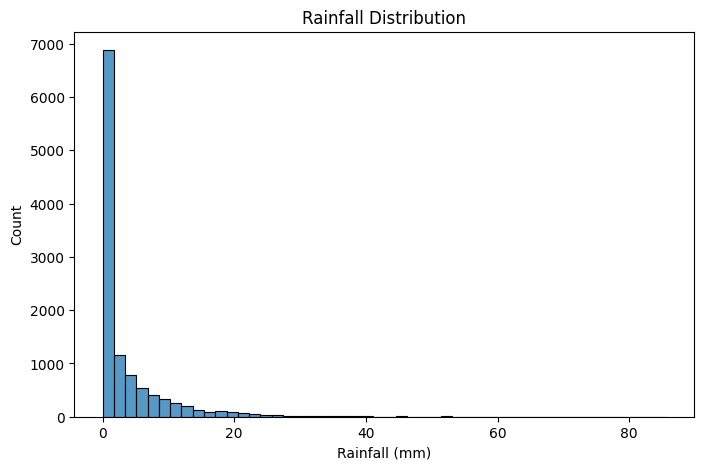

In [99]:
plt.figure(figsize=(8,5))
sns.histplot(df["PRECTOTCORR"], bins=50)
plt.title("Rainfall Distribution")
plt.xlabel("Rainfall (mm)")
plt.show()

## Rainfall Over Time

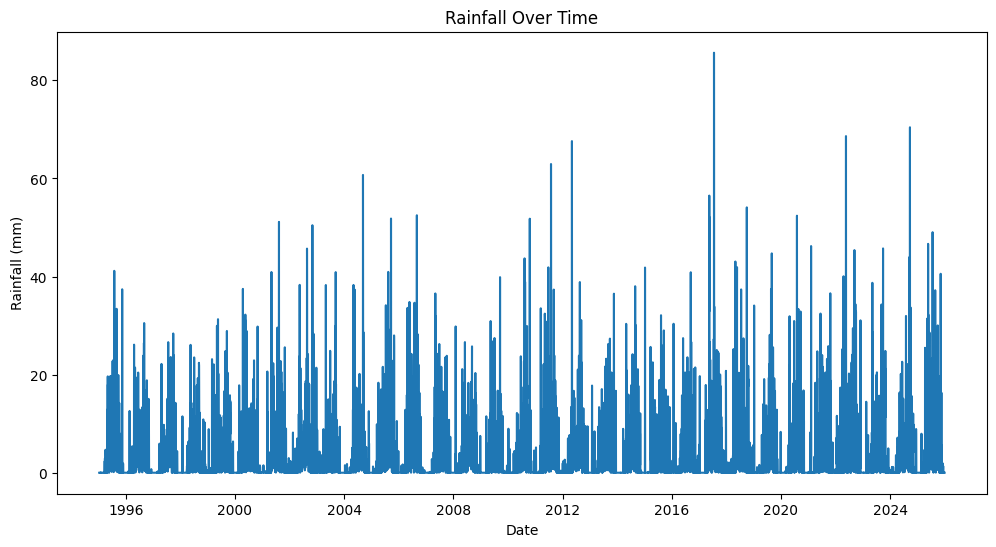

In [100]:
plt.figure(figsize=(12,6))
plt.plot(df["DATE"], df["PRECTOTCORR"])
plt.title("Rainfall Over Time")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.show()

## Monthly Rainfall Distribution

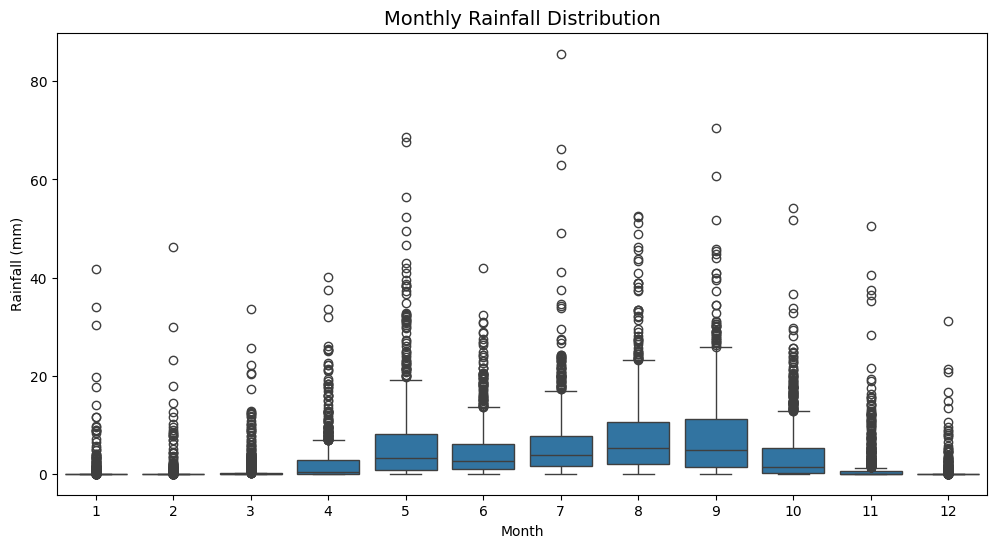

In [101]:
plt.figure(figsize=(12,6))

sns.boxplot(x="MONTH", y="PRECTOTCORR", data=df)

plt.title("Monthly Rainfall Distribution", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")

plt.show()

## Average Monthly Rainfall

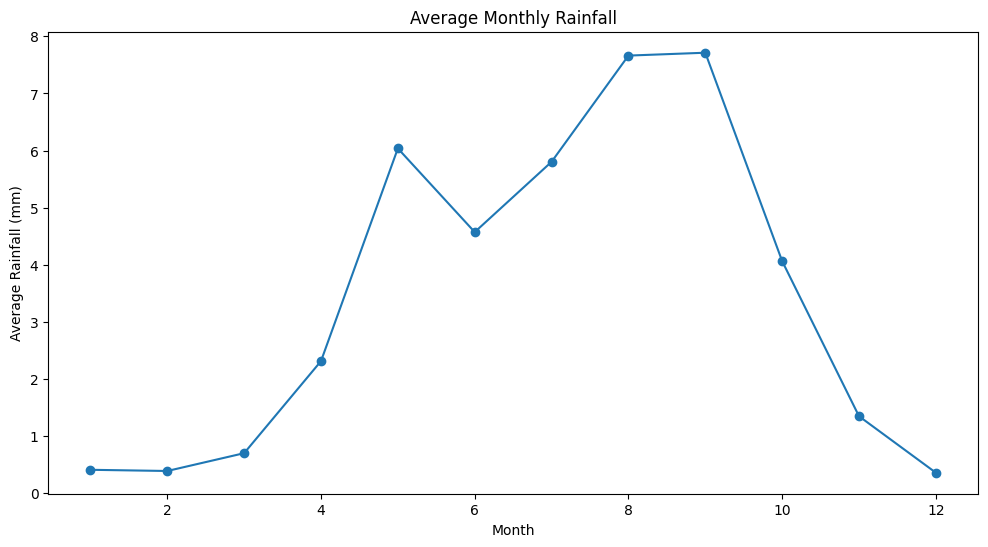

In [102]:
monthly_rain = df.groupby("MONTH")["PRECTOTCORR"].mean()

plt.figure(figsize=(12,6))
monthly_rain.plot(marker='o')

plt.title("Average Monthly Rainfall")
plt.xlabel("Month")
plt.ylabel("Average Rainfall (mm)")

plt.show()

## Correlation Analysis

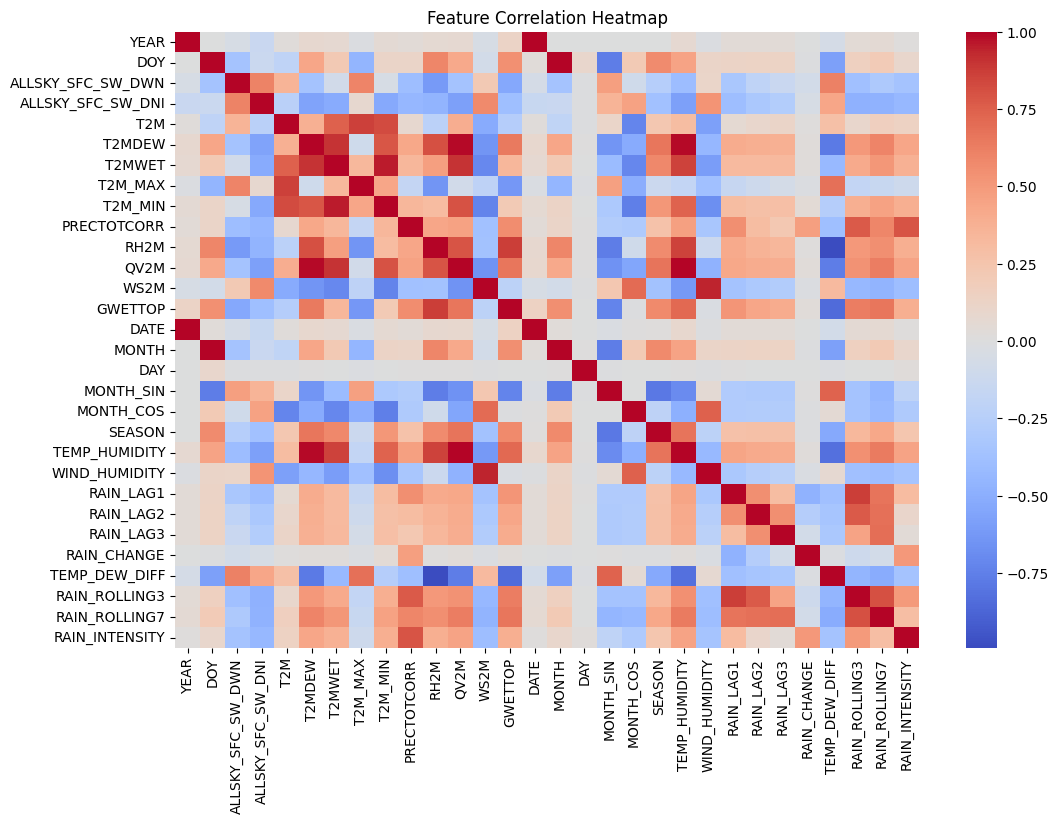

In [103]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

This helps identify features strongly correlated with rainfall.

# 8. Train/Test Split

To simulate real-world forecasting, we use a time-based split.

Training Data: 1995–2020  
Testing Data: 2021–2025

In [124]:
# ---------------------------
# Step 1: Separate periods
# ---------------------------

train_test_df = df[df["YEAR"] <= 2020]
future_df = df[df["YEAR"] > 2020]

print("Train/Test dataset:", train_test_df.shape)
print("Future prediction dataset:", future_df.shape)

Train/Test dataset: (9488, 30)
Future prediction dataset: (1826, 30)


# 9. Feature Selection
Define features.

In [125]:
features = [
"RH2M",
"GWETTOP",
"T2MDEW",
"T2M_MIN",
"WS2M",
"RAIN_LAG1",
"RAIN_LAG2",
"RAIN_LAG3",
"RAIN_ROLLING3",
"RAIN_ROLLING7",
"RAIN_CHANGE",
"RAIN_INTENSITY",
"TEMP_DEW_DIFF"
]

target = "PRECTOTCORR"

In [126]:
X = train_test_df[features]
y = train_test_df[target]

In [127]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (7590, 13)
Test shape: (1898, 13)


# 9. Feature Scaling
Scaling improves ML model performance.

In [128]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 10. PCA (Dimensionality Reduction)
## Reduce dimensionality while preserving variance.

In [129]:
from sklearn.decomposition import PCA

pca = PCA(0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [130]:
print("Number of components selected:", pca.n_components_)
print("Explained variance ratio of components:")

for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"Component {i+1}: {v:.4f}")

print("Total explained variance:", sum(pca.explained_variance_ratio_))

Number of components selected: 7
Explained variance ratio of components:
Component 1: 0.4975
Component 2: 0.1483
Component 3: 0.1103
Component 4: 0.0842
Component 5: 0.0736
Component 6: 0.0296
Component 7: 0.0234
Total explained variance: 0.9669025499301528


## Plot explained variance.

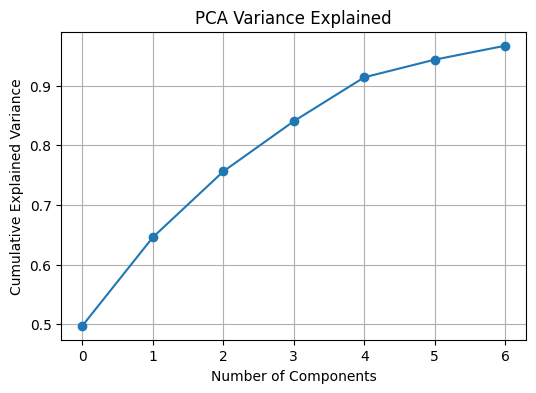

In [131]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Variance Explained")

plt.grid(True)
plt.show()

# 12. Model Training

Multiple machine learning models are trained to predict daily rainfall.

Models used:
- Decision Tree
- Random Forest
- Support Vector Regression

In [111]:
!pip install xgboost

In [132]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [133]:
def evaluate_model(model, X_train, X_test, y_train, y_test, name):

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    result = {
        "Model": name,

        "R2 Train": r2_score(y_train, y_train_pred),
        "R2 Test": r2_score(y_test, y_test_pred),

        "RMSE Train": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "RMSE Test": np.sqrt(mean_squared_error(y_test, y_test_pred)),

        "MAE Train": mean_absolute_error(y_train, y_train_pred),
        "MAE Test": mean_absolute_error(y_test, y_test_pred),

        "MSE Train": mean_squared_error(y_train, y_train_pred),
        "MSE Test": mean_squared_error(y_test, y_test_pred)
    }

    return result

In [134]:
results = []

# Linear Regression
lr = LinearRegression()
results.append(evaluate_model(lr, X_train_scaled, X_test_scaled, y_train, y_test, "Linear Regression"))

# Decision Tree
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
results.append(evaluate_model(dt, X_train, X_test, y_train, y_test, "Decision Tree"))

# Random Forest
rf = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42)
results.append(evaluate_model(rf, X_train, X_test, y_train, y_test, "Random Forest"))

# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4)
results.append(evaluate_model(gb, X_train, X_test, y_train, y_test, "Gradient Boosting"))

# XGBoost
xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6)
results.append(evaluate_model(xgb, X_train, X_test, y_train, y_test, "XGBoost"))

# LightGBM
lgbm = LGBMRegressor(n_estimators=500, learning_rate=0.05)
results.append(evaluate_model(lgbm, X_train, X_test, y_train, y_test, "LightGBM"))

# SVR
svr = SVR(kernel='rbf', C=10)
results.append(evaluate_model(svr, X_train_pca, X_test_pca, y_train, y_test, "SVR"))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000341 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2929
[LightGBM] [Info] Number of data points in the train set: 7590, number of used features: 13
[LightGBM] [Info] Start training from score 3.338296


In [151]:
import pickle

# save the trained best model
with open("rainfall_prediction_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

print("Model saved successfully as rainfall_prediction_model.pkl")

Model saved successfully as rainfall_prediction_model.pkl


In [152]:
import pickle

# load the saved model
with open("rainfall_prediction_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Model loaded successfully")

Model loaded successfully


In [153]:
import numpy as np

# example input values
user_input = np.array([[

70,      # RH2M
0.3,     # GWETTOP
22.5,    # T2MDEW
20.1,    # T2M_MIN
2.5,     # WS2M
1.2,     # RAIN_LAG1
0.8,     # RAIN_LAG2
0.5,     # RAIN_LAG3
1.1,     # RAIN_ROLLING3
0.9,     # RAIN_ROLLING7
0.4,     # RAIN_CHANGE
0.7,     # RAIN_INTENSITY
2.4      # TEMP_DEW_DIFF

]])

prediction = loaded_model.predict(user_input)

print("Predicted Rainfall (mm):", prediction[0])

Predicted Rainfall (mm): 1.3644756


In [135]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values("RMSE Test")

print(results_df)

               Model  R2 Train   R2 Test    RMSE Train     RMSE Test  \
0  Linear Regression  1.000000  1.000000  1.094100e-14  1.062756e-14   
4            XGBoost  0.999944  0.996187  4.587176e-02  3.608646e-01   
3  Gradient Boosting  0.999103  0.995725  1.838949e-01  3.821110e-01   
2      Random Forest  0.998509  0.995701  2.371144e-01  3.831784e-01   
5           LightGBM  0.998354  0.995221  2.491867e-01  4.040080e-01   
6                SVR  0.969390  0.986329  1.074472e+00  6.832738e-01   
1      Decision Tree  0.997968  0.973670  2.768536e-01  9.482535e-01   

      MAE Train      MAE Test     MSE Train      MSE Test  
0  8.773889e-15  8.539063e-15  1.197055e-28  1.129450e-28  
4  2.593803e-02  1.098854e-01  2.104218e-03  1.302233e-01  
3  1.058524e-01  1.608734e-01  3.381733e-02  1.460088e-01  
2  4.813055e-02  1.032689e-01  5.622325e-02  1.468257e-01  
5  5.366010e-02  1.257581e-01  6.209400e-02  1.632224e-01  
6  2.145441e-01  2.404956e-01  1.154489e+00  4.668631e-01  
1  

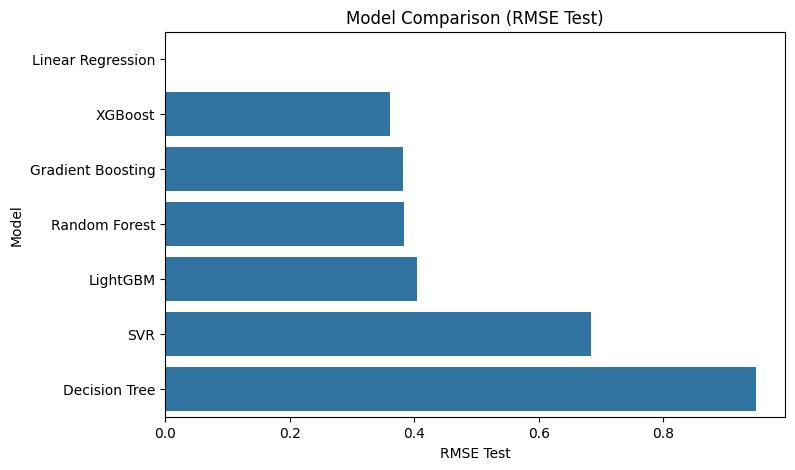

In [136]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(x="RMSE Test", y="Model", data=results_df)

plt.title("Model Comparison (RMSE Test)")
plt.show()

In [137]:
X_future = future_df[features]

future_predictions = xgb.predict(X_future)

future_df["Predicted_Rainfall"] = future_predictions

In [138]:
best_model = xgb  # your trained XGBoost model

# Predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

metrics_table = pd.DataFrame({
    "Metric": ["R2 Score", "RMSE", "MAE", "MSE"],
    
    "Training Set": [
        r2_score(y_train, y_train_pred),
        np.sqrt(mean_squared_error(y_train, y_train_pred)),
        mean_absolute_error(y_train, y_train_pred),
        mean_squared_error(y_train, y_train_pred)
    ],
    
    "Test Set": [
        r2_score(y_test, y_test_pred),
        np.sqrt(mean_squared_error(y_test, y_test_pred)),
        mean_absolute_error(y_test, y_test_pred),
        mean_squared_error(y_test, y_test_pred)
    ]
})

metrics_table

,Metric,Training Set,Test Set
0,R2 Score,0.999944,0.996187
1,RMSE,0.045872,0.360865
2,MAE,0.025938,0.109885
3,MSE,0.002104,0.130223


In [139]:
# unseen data
future_df = df[df["YEAR"] > 2020]

X_future = future_df[features]

# prediction
future_predictions = best_model.predict(X_future)

future_df["Predicted_Rainfall"] = future_predictions

In [140]:
prediction_table = future_df[["DATE", "PRECTOTCORR", "Predicted_Rainfall"]]

prediction_table = prediction_table.rename(columns={
    "DATE": "Date",
    "PRECTOTCORR": "Actual Rainfall (mm)",
    "Predicted_Rainfall": "Predicted Rainfall (mm)"
})

prediction_table.head()

,Date,Actual Rainfall (mm),Predicted Rainfall (mm)
9497,2021-01-01,0.0,-0.003415
9498,2021-01-02,0.0,-0.002305
9499,2021-01-03,0.0,-0.000392
9500,2021-01-04,0.0,-0.000392
9501,2021-01-05,0.0,-0.000392


In [141]:
prediction_table.to_csv("rainfall_predictions_2021_2025.csv", index=False)

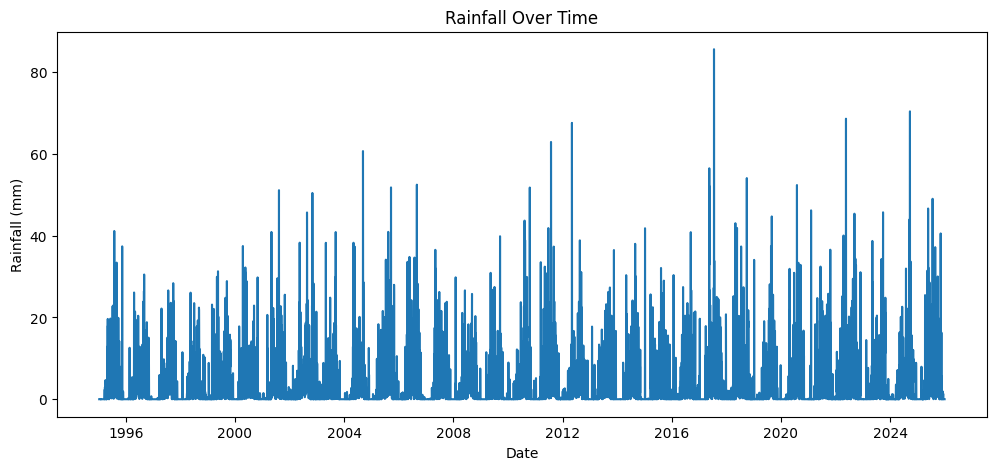

In [142]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(df["DATE"], df["PRECTOTCORR"])

plt.title("Rainfall Over Time")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")

plt.show()

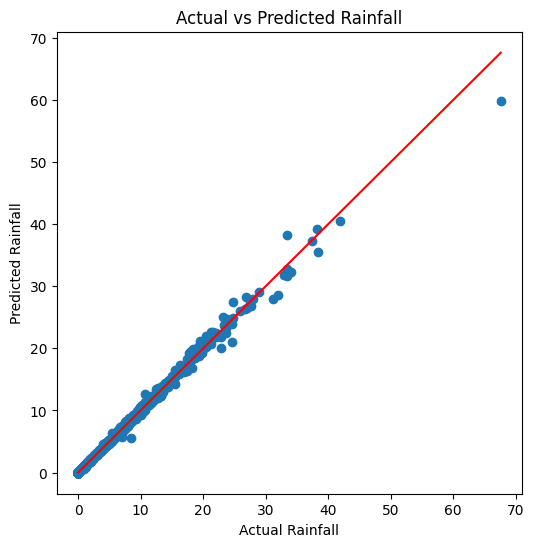

In [143]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_test_pred)

plt.xlabel("Actual Rainfall")
plt.ylabel("Predicted Rainfall")

plt.title("Actual vs Predicted Rainfall")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.show()

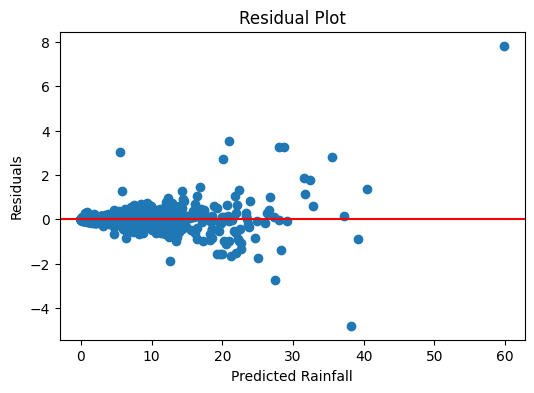

In [144]:
residuals = y_test - y_test_pred

plt.figure(figsize=(6,4))

plt.scatter(y_test_pred, residuals)

plt.axhline(y=0, color="red")

plt.xlabel("Predicted Rainfall")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

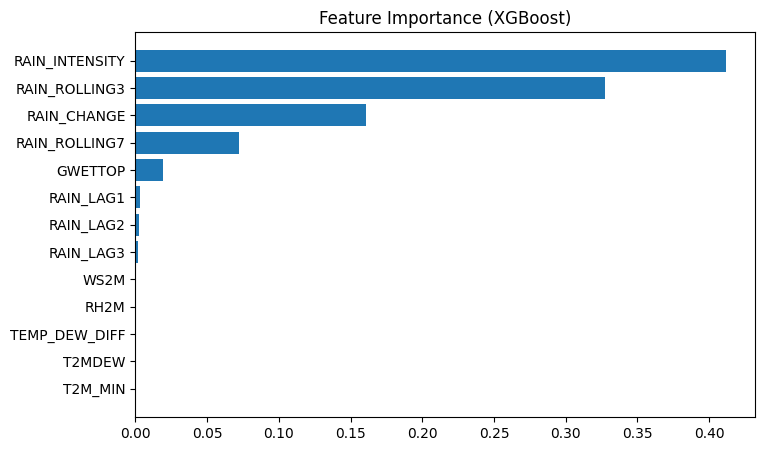

In [145]:
importances = best_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))

plt.barh(importance_df["Feature"], importance_df["Importance"])

plt.gca().invert_yaxis()

plt.title("Feature Importance (XGBoost)")

plt.show()

In [146]:
# predictions from best model
y_test_pred = best_model.predict(X_test)

# create dataframe
comparison_df = pd.DataFrame({
    "Actual Rainfall": y_test.values,
    "Predicted Rainfall": y_test_pred
})

comparison_df.reset_index(drop=True, inplace=True)

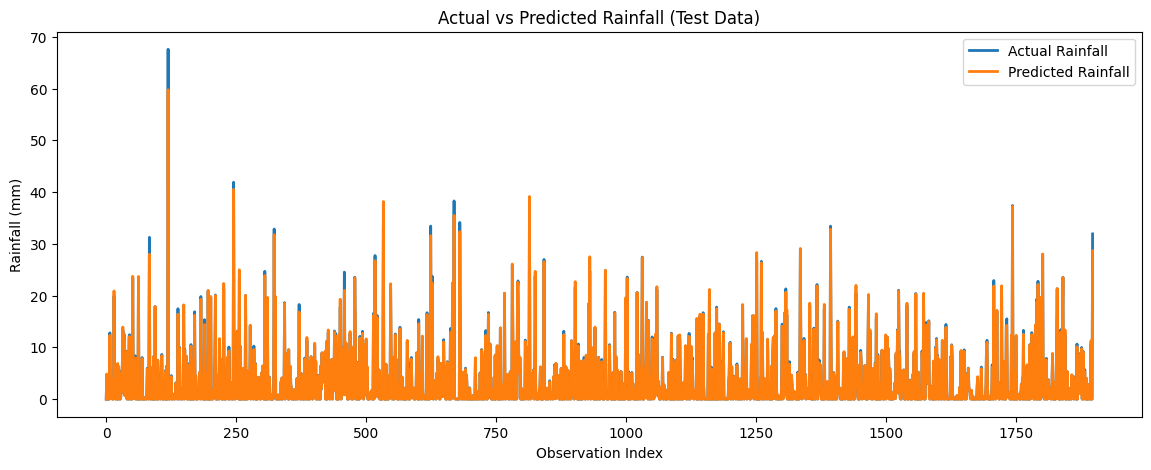

In [147]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.plot(comparison_df["Actual Rainfall"], label="Actual Rainfall", linewidth=2)
plt.plot(comparison_df["Predicted Rainfall"], label="Predicted Rainfall", linewidth=2)

plt.title("Actual vs Predicted Rainfall (Test Data)")
plt.xlabel("Observation Index")
plt.ylabel("Rainfall (mm)")

plt.legend()

plt.show()

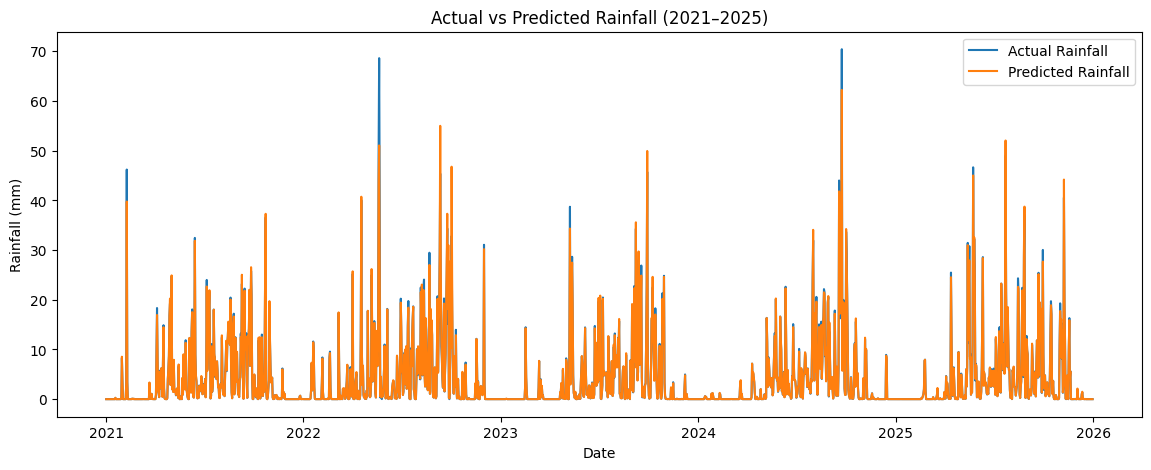

In [148]:
plt.figure(figsize=(14,5))

plt.plot(future_df["DATE"], future_df["PRECTOTCORR"], label="Actual Rainfall")
plt.plot(future_df["DATE"], future_df["Predicted_Rainfall"], label="Predicted Rainfall")

plt.title("Actual vs Predicted Rainfall (2021–2025)")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")

plt.legend()

plt.show()

In [149]:
plt.savefig("actual_vs_predicted_rainfall.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [150]:
df.to_csv("cleaned_rainfall_dataset.csv", index=False)
print("Cleaned dataset saved.")

Cleaned dataset saved.


In [154]:
import numpy as np

RH2M = float(input("Enter RH2M: "))
GWETTOP = float(input("Enter GWETTOP: "))
T2MDEW = float(input("Enter T2MDEW: "))
T2M_MIN = float(input("Enter T2M_MIN: "))
WS2M = float(input("Enter WS2M: "))
RAIN_LAG1 = float(input("Enter RAIN_LAG1: "))
RAIN_LAG2 = float(input("Enter RAIN_LAG2: "))
RAIN_LAG3 = float(input("Enter RAIN_LAG3: "))
RAIN_ROLLING3 = float(input("Enter RAIN_ROLLING3: "))
RAIN_ROLLING7 = float(input("Enter RAIN_ROLLING7: "))
RAIN_CHANGE = float(input("Enter RAIN_CHANGE: "))
RAIN_INTENSITY = float(input("Enter RAIN_INTENSITY: "))
TEMP_DEW_DIFF = float(input("Enter TEMP_DEW_DIFF: "))

user_data = np.array([[

RH2M,
GWETTOP,
T2MDEW,
T2M_MIN,
WS2M,
RAIN_LAG1,
RAIN_LAG2,
RAIN_LAG3,
RAIN_ROLLING3,
RAIN_ROLLING7,
RAIN_CHANGE,
RAIN_INTENSITY,
TEMP_DEW_DIFF

]])

prediction = loaded_model.predict(user_data)

print("Predicted Rainfall:", prediction[0], "mm")

Enter RH2M:  0.9
Enter GWETTOP:  0
Enter T2MDEW:  1
Enter T2M_MIN:  1
Enter WS2M:  1
Enter RAIN_LAG1:  1
Enter RAIN_LAG2:  1
Enter RAIN_LAG3:  1
Enter RAIN_ROLLING3:  1
Enter RAIN_ROLLING7:  1
Enter RAIN_CHANGE:  1
Enter RAIN_INTENSITY:  1
Enter TEMP_DEW_DIFF:  1


Predicted Rainfall: 1.798432 mm
